In [2]:
import pandas as pd

data_path = "./data/mexico-real-estate-combined-clean.csv"

df = pd.read_csv(data_path)

print(f"Dimension: {df.shape[0]} rows and {df.shape[1]} columns")
print(df.info())
df.head()

Dimension: 1736 rows and 6 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1736 non-null   object 
 1   state          1736 non-null   object 
 2   lat            1736 non-null   float64
 3   lon            1736 non-null   float64
 4   area_m2        1736 non-null   float64
 5   price_usd      1736 non-null   float64
dtypes: float64(4), object(2)
memory usage: 81.5+ KB
None


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


Matplotlib also provides a shortcut, ax.set(title=..., xlabel=..., ylabel=..., xlim=...), which bundles several of these into one call.

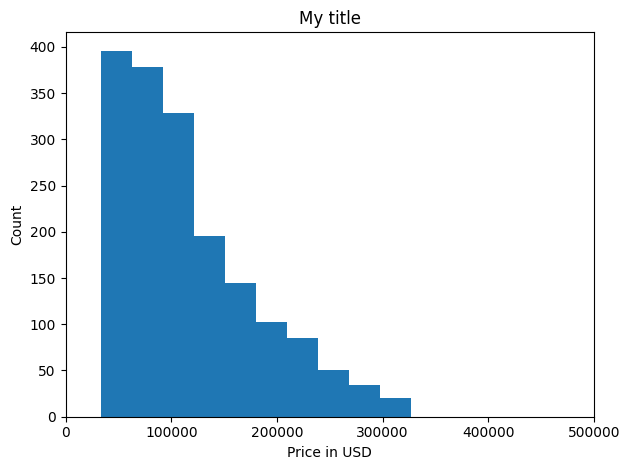

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(df["price_usd"])
ax.set_title("My title")
ax.set_xlabel("Price in USD")
ax.set_ylabel("Count")
ax.set_xlim(0, 500000)

plt.tight_layout()
plt.show()

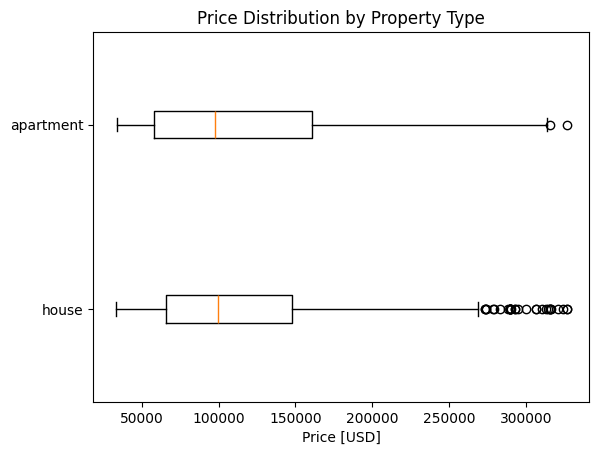

In [4]:
prop_types = df["property_type"].unique()

data_by_type = [df[df["property_type"] == label]["price_usd"] for label in prop_types]

fig, ax = plt.subplots()
ax.boxplot(data_by_type, tick_labels=prop_types, vert=False)
ax.set_title("Price Distribution by Property Type")
ax.set_xlabel("Price [USD]")
plt.show()

Below is the boxplot comparing price for 3 different states.

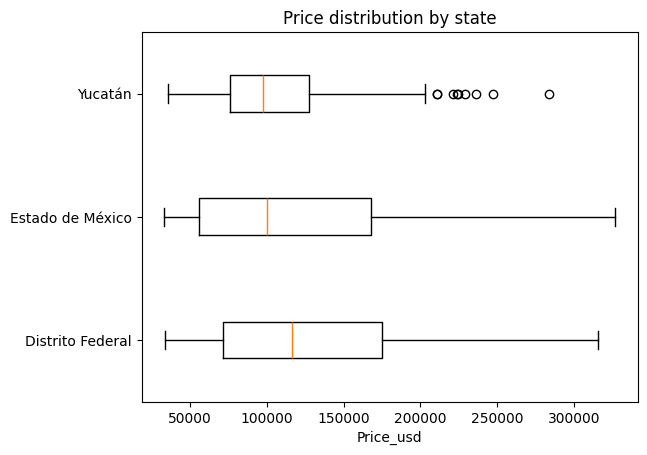

In [5]:
# 1. Define your selected states
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
    .index.tolist()
)
# 2. Prepare the data
data_by_state = [df[df["state"] == state]["price_usd"] for state in selected_states]

# 3. Plot
fig, ax = plt.subplots()

# FIX: Use 'tick_labels' instead of 'labels'
ax.boxplot(data_by_state, tick_labels=selected_states, vert=False)

ax.set_title("Price distribution by state")
ax.set_xlabel("Price_usd")
plt.show()

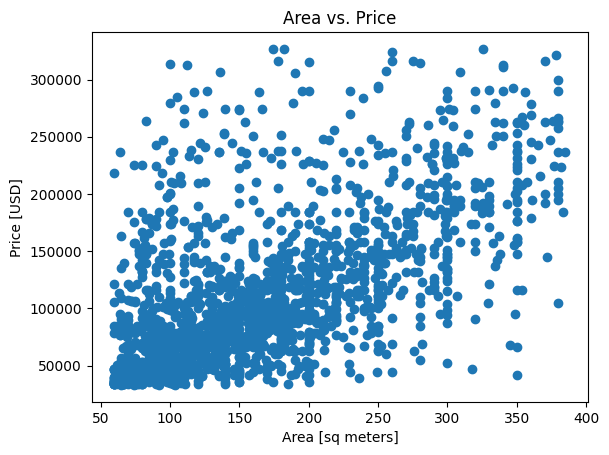

In [6]:
fig, ax = plt.subplots()

ax.scatter(x=df["area_m2"], y=df["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price")

plt.show()

  property_type             state        lat         lon  area_m2  price_usd
0         house  Estado de México  19.560181  -99.233528    150.0   67965.56
1         house        Nuevo León  25.688436 -100.198807    186.0   63223.78
2     apartment          Guerrero  16.767704  -99.764383     82.0   84298.37
3     apartment          Guerrero  16.829782  -99.911012    150.0   94308.80
4         house           Yucatán  21.052583  -89.538639    205.0  105191.37
Original: 1736 rows
Cleaned: 1365 rows
Removed: 371 rows


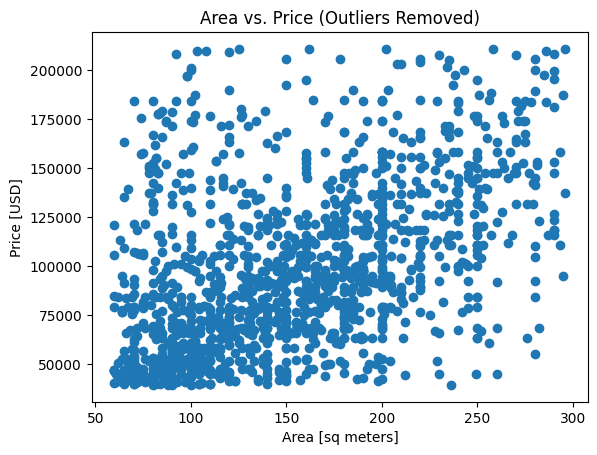

In [7]:
# Define cutoff percentages
lower_cut = 0.05  # Remove bottom 5%
upper_cut = 0.90  # Keep up to 90th percentile

# Filter the data
df_clean = (
    df[
        (df["price_usd"] > df["price_usd"].quantile(lower_cut)) &
        (df["price_usd"] < df["price_usd"].quantile(upper_cut)) &
        (df["area_m2"] < df["area_m2"].quantile(upper_cut)) # <-- Large area outliers also skew the scatter plot
    ]
)

# Show what changed
print(df_clean.head())
print(f"Original: {len(df)} rows")
print(f"Cleaned: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

# Plot
fig, ax = plt.subplots()
ax.scatter(df_clean["area_m2"], df_clean["price_usd"])
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price (Outliers Removed)")
plt.show()

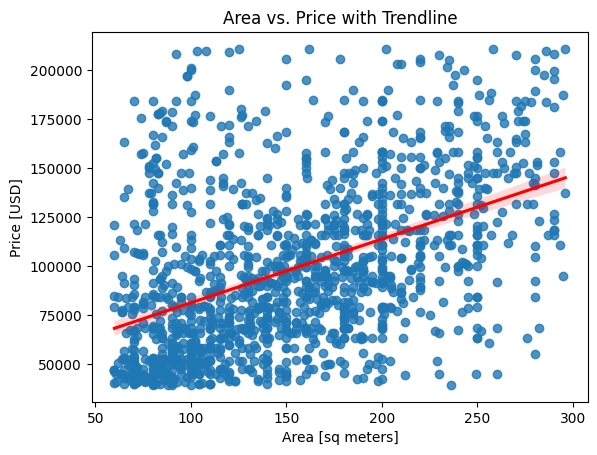

In [8]:
# remember to import your library if you haven't
import seaborn as sns

# Create figure and axis explicitly
fig, ax = plt.subplots()

# Use Seaborn to plot scatter + trendline
sns.regplot(
    data=df_clean, 
    x="area_m2", 
    y="price_usd", 
    line_kws={"color": "red"},  # Make the line distinct
    ax=ax  # Pass the axis to seaborn
)

ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Area vs. Price with Trendline")
plt.show()

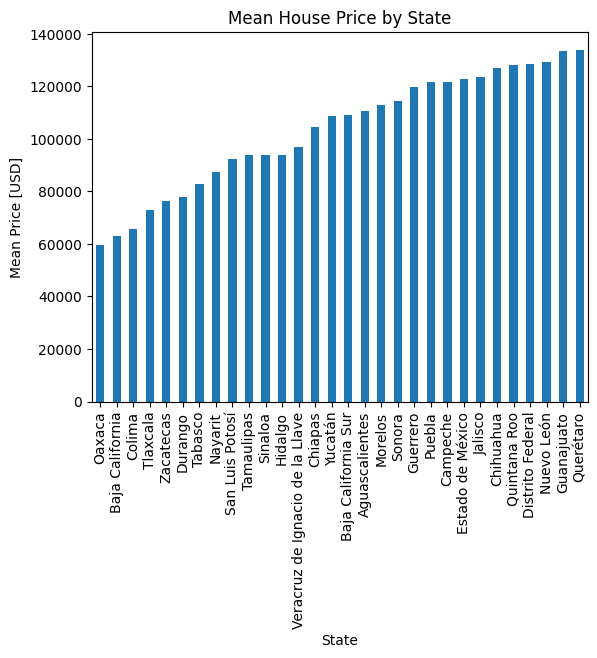

In [9]:
# Aggregate data using groupby
mean_price_by_state = (
    df.groupby("state")["price_usd"]  # <-- "state" & "price_usd"
    .mean()
    .sort_values(ascending=True or False) # <-- pass in True or False to sort
)

# Create figure and axes explicitly
fig, ax = plt.subplots()

# Use pandas plot method with explicit axes
mean_price_by_state.plot(
    kind="bar",
    ax=ax  # Pass the axes to pandas
)

# Customize using Matplotlib methods
ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.set_title("Mean House Price by State")

plt.show()

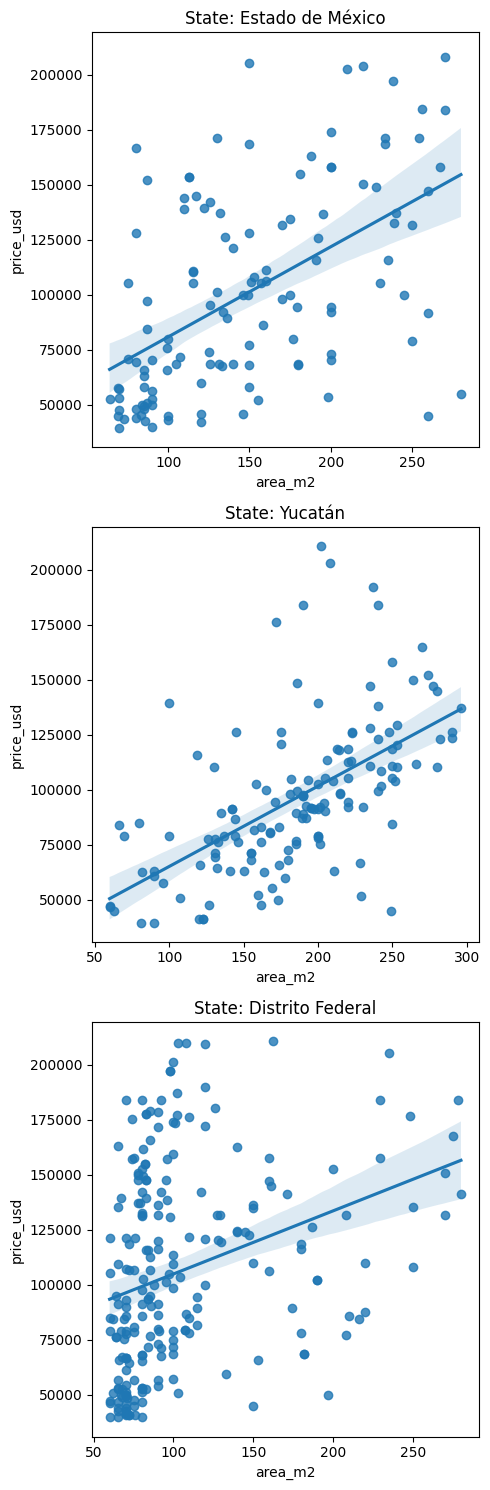

In [10]:
## 1. Create your custom figure and axes
fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharey=True)

# 2. Create a list of the top 3 states
top_states = selected_states  # <--- pass selected_states

# 3. Filter df_clean to include only these states
df_states = df_clean[df_clean["state"].isin(top_states)]

# 4. Loop through the states and plot on each specific axis
states = df_states["state"].unique()

for ax, state in zip(axes, states):
    # Filter data for the current state
    subset = df_states[df_states["state"] == state]
    
    # Use regplot (Axes-level) which ACCEPTS 'ax='
    sns.regplot(
        data=subset,
        x="area_m2",  # <--- "area_m2"
        y="price_usd",  # <--- "price_usd" 
        color='tab:blue', # Optional: keep colors consistent
        ax=ax # <--- This is where you pass the axis explicitly
    )
    
    ax.set_title(f"State: {state}")

plt.tight_layout()
plt.show()